# Gridworld Value Iteration (4×4)

A warm-up before CartPole: implementing value iteration by hand on a
4×4 Gridworld. The transition model P is explicitly constructed (model-based),
which is the key contrast with the model-free Q-learning that follows.

- Two terminal states at corners (0,0) and (3,3), reward -1 per step
- Bellman optimality update: V(s) = max_a [ r + γ·V(s') ]
- Converges to the ground-truth value function

In [1]:
import numpy as np

N = 4
n_states = N * N
terminals = {(0, 0), (3, 3)}
gamma = 1.0
actions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
V = np.zeros((4, 4))

def step(r, c, dr, dc):
    new_r = r + dr
    new_c = c + dc

    # Pulling values that exceed the boundaries back to the boundary edge, 
    # this handles the actions that go beyond the boundaries.
    new_r = max(0, min(3, new_r))
    new_c = max(0, min(3, new_c))

    # The reward is always -1
    reward = -1

    return ((new_r, new_c), reward)
    
for iteration in range(100):

    for r in range(4):
        for c in range(4):

            #The start and end point detection. These two points act as the base condition for this recursion. 
            #Therefore, even if gamma is 1, there can still be accurate values.
            if (r, c) in terminals:
                    continue

            candidates = []
            for dr, dc in actions:
                (new_r, new_c), reward = step(r, c, dr, dc)
                
                #Bellman equation
                candidate = reward + gamma * (V[new_r, new_c])

                candidates.append(candidate)

            V[r, c] = max(candidates)

print(V)    

[[ 0. -1. -2. -3.]
 [-1. -2. -3. -2.]
 [-2. -3. -2. -1.]
 [-3. -2. -1.  0.]]


## Greedy Policy Extraction

Given the converged value function V, extract the optimal policy: for each
state, pick the action that leads to the highest-value neighbor
(argmax over actions). Visualized as an arrow grid.

Note: this uses V + the model to compute each action's value on the fly —
which is exactly Q(s,a). In model-free Q-learning we store Q directly instead.

In [2]:
arrow = {(-1, 0): "↑", (1, 0): "↓", (0, -1): "←", (0, 1): "→"}

policy = [[""for _ in range(4)]for _ in range(4)]

for r in range(4):
    for c in range(4):

        # The first time I wrote, I forgot to use "continue", 
        #which resulted in not being able to print out "T" and 
        #it was overwritten by the subsequent loop.
        if (r, c) in terminals:
            policy[r][c] = "T"
            continue

        best_value = float('-inf')
        best_action = None

        for (dr, dc) in actions:
            (new_r, new_c), reward = step(r, c, dr, dc)
            candidate = reward + gamma * (V[new_r, new_c])

            if candidate > best_value:
                best_value = candidate
                best_action = (dr, dc)

        #list and dic both use the "[]" to access the value    
        policy[r][c] = arrow[best_action]
        
# "".join can change the connection forms of various string types such as list tuples.
for row in policy:
    print(" ".join(row))
        
        

T ← ← ↓
↑ ↑ ↑ ↓
↑ ↑ ↓ ↓
↑ → → T


In [3]:
print(step(2, 2, -1, 0))   
print(step(0, 0, -1, 0))  
print(step(3, 3, 0, 1))  

((1, 2), -1)
((0, 0), -1)
((3, 3), -1)


## TD Learning Warm-up: Value Propagation (S1→S2→S3)

Minimal TD(0) demo on a 3-state chain to see the core mechanism:
the true value (reward=10 at terminal S3) propagates backward one layer
per sweep — after1 [0,0,10] → after2 [0,10,10] → after3 [10,10,10].
This is the "value washing back from the terminal" idea in its simplest form.

In [4]:
import numpy as np

gamma = 1
alpha = 1

v = np.zeros(3)

def step(i):
    if i == 2:
        reward = 10
        next_value = 0
        return reward, next_value

    else:
        reward = 0
        next_value = v[i + 1]
        return reward, next_value

print(v)


[0. 0. 0.]


In [5]:
for episode in range(3):

    for i in range(3):
        reward, next_value = step(i)
        td_target = reward + gamma * next_value

        v[i] = v[i] + alpha * (td_target - v[i])

    print(f"after{episode + 1}, v = {v}")

after1, v = [ 0.  0. 10.]
after2, v = [ 0. 10. 10.]
after3, v = [10. 10. 10.]


# CartPole-v1: Environment & Random Baseline

## 1. Understanding the Environment Interface
Explore CartPole's API: reset(), step() returning (obs, reward,
terminated, truncated, info), and the 4-dim continuous observation (Box).

In [6]:
import gymnasium as gym
print(gym.__version__)

1.3.0


In [7]:
env = gym.make("CartPole-v1")

#print("action_space:", env.action_space)
#print("observation_space:", env.observation_space)

observation, info = env.reset(seed = 42)
print("state is", observation)
print("style is", type(observation))
print("shape is", observation.shape)
print("info is", info)

action = 1
next_observation, reward, terminated, truncated, info = env.step(action)

print("action", action)
print("new observation is", next_observation)
print("reward is", reward)
print("terminated", terminated)
print("truncated", truncated)

state is [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
style is <class 'numpy.ndarray'>
shape is (4,)
info is {}
action 1
new observation is [ 0.02727336  0.18847767  0.03625453 -0.26141977]
reward is 1.0
terminated False
truncated False


## 2. Single Episode with Random Policy

In [8]:
observation, info = env.reset(seed = 42)

total_reward = 0
steps = 0

while True:
    action = env.action_space.sample()

    next_observation, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    steps += 1

    if terminated or truncated:
        break

    observation = next_observation

print(f"This round lasted for {steps}, total_reward is {total_reward}")
    

This round lasted for 10, total_reward is 10.0


## 3. Random Baseline over 20 Episodes
Average ~22 steps. This is the baseline that tabular Q-learning
must beat later.

In [9]:
import numpy as np

episode_reward = []

for episode in range(20):

    # The first time I wrote it without including this, the reward remained at 0
    observation, info = env.reset()
    total_reward = 0
    steps = 0

    while True:
        
        action = env.action_space.sample()
        next_observation, reward, terminated, truncated, info = env.step(action)
        
        total_reward += reward
        steps += 1
        
        if terminated or truncated:
            break
            
        observation = next_observation
    # episode_reward = episode_reward.append(total_reward), This way of writing is incorrect.
    episode_reward.append(total_reward)

episode_reward = np.array(episode_reward)
print(f"20 episodes average reward is {episode_reward.mean():.1f}")
print(f"the standard of reward is {episode_reward.std():.1f}")
print(f"the max is {episode_reward.max()}")
print(f"the min is {episode_reward.min()}")
    

        

20 episodes average reward is 20.4
the standard of reward is 9.1
the max is 44.0
the min is 10.0


# Tabular Q-learning on CartPole-v1

## 1. State Discretization
Convert CartPole's continuous 4-dim state into discrete bin indices,
so a tabular Q-table can index it (continuous → buckets, a lossy but
necessary step for tabular methods).

In [11]:
import numpy as np
import gymnasium as gym

env = gym.make("CartPole-v1")
state, info = env.reset()

N_BINS = (6, 6, 12, 12)

STATE_BOUNDS = [
    (-4.8, 4.8),
    (-3.0, 3.0),
    (-0.418, 0.418),
    (-3.5, 3.5),
]

def discretize(state):

    indices = []
    for i in range(4):
        low, high = STATE_BOUNDS[i]

        #Here, the beginning and the end should be removed.
        bins = np.linspace(low, high, N_BINS[i] + 1)[1: -1]
        idx = np.digitize(state[i], bins)
        
        indices.append(idx)
    return tuple(indices)
    


## 2. Q-table & ε-greedy Action Selection
Q-table shape = 4 state dims + 1 action dim, init to zeros.
ε-greedy: explore randomly with prob ε, otherwise exploit (argmax Q).

In [12]:

#"Sample" refers to a random selection, 
#while "n" represents the total number of actions.
n_actions = env.action_space.n

#(n_actions,) - Convert it to a tuple
q_table_shape =N_BINS + (n_actions,)
Q = np.zeros(q_table_shape)

def choose_action(state, epsilon):

    # Early on, epsilon is large: mostly random exploration to fill the Q-table.
    # It then decays so greedy exploitation dominates.
    if np.random.random() < epsilon:
        action = env.action_space.sample()

    else:
        s = discretize(state)
        action = np.argmax(Q[s])
    return action




## 3. Sanity Check
ε=0 → always exploits (prints 0, since Q is all-zero → argmax picks action 0).
ε=1 → always explores (mix of 0s and 1s). Confirms choose_action works.

In [13]:
print("Continuous state", state)
print("after discretization", discretize(state))
print("Q-table shape:", Q.shape)
print("Pure exploitation:", choose_action(state, 0.0))
print("Pure exploration:", [choose_action(state, 1.0) for _ in range(10)])

Continuous state [-0.03894392 -0.01556105  0.01637915  0.04855577]
after discretization (np.int64(2), np.int64(2), np.int64(6), np.int64(6))
Q-table shape: (6, 6, 12, 12, 2)
Pure exploitation: 0
Pure exploration: [np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0)]


## 4. Q-learning Update Rule

Q(s,a) ← Q(s,a) + α·[ r + γ·max_a' Q(s',a') − Q(s,a) ]

- if done: no future, td_target = reward (terminal T bootstraps to 0)
- else: td_target = r + γ·max Q(s'), using max (not the actual next action)
  → this is what makes Q-learning off-policy: it learns the optimal policy
    while behaving with ε-greedy exploration.

In [14]:
alpha = 0.1
gamma = 0.99

def update(state, next_state, action, reward, done):
    s = discretize(state)
    s_next = discretize(next_state)

    if done:
        td_target = reward

    else:
        best_next = np.max(Q[s_next])
        td_target = reward + gamma * best_next

    td_error = td_target - Q[s][action]
    Q[s][action] = Q[s][action] + alpha * td_error

## 5. Training Loop

Run 2000 episodes with ε decaying from 1.0 to 0.05.
Each step: choose_action → env.step → update Q → move to next state.

Note: `done = terminated or truncated` must be set after step and before
the next iteration, so the terminal step's update uses the correct done flag.

In [16]:
n_episode = 2000
epsilon = 1.0
epsilon_min = 0.05
decay = 0.99
episode_reward = []

for episode in range(n_episode):
    state, info = env.reset()
    total_reward = 0
    done = False
    

    while not done:

        action = choose_action(state, epsilon)
        (next_state, reward, terminated, truncated, info) = env.step(action)

        update(state, next_state, action, reward, done)

        # done = terminated (pole fell / failed) or truncated (hit 500-step cap).
        # Either ends the episode.
        done = terminated or truncated
        
        state = next_state
        total_reward +=reward
        
    # epsilon decays: shift from exploration (early, Q unreliable) to
    # exploitation (later, Q trustworthy).
    epsilon = max(epsilon_min, epsilon * decay)
    episode_reward.append(total_reward)


    if episode % 100 == 0:   
        print(f"Episode {episode}, epsilon {epsilon:.3f}, reward {total_reward}")

Episode 0, epsilon 0.990, reward 12.0
Episode 100, epsilon 0.362, reward 56.0
Episode 200, epsilon 0.133, reward 158.0
Episode 300, epsilon 0.050, reward 132.0
Episode 400, epsilon 0.050, reward 124.0
Episode 500, epsilon 0.050, reward 113.0
Episode 600, epsilon 0.050, reward 108.0
Episode 700, epsilon 0.050, reward 133.0
Episode 800, epsilon 0.050, reward 159.0
Episode 900, epsilon 0.050, reward 119.0
Episode 1000, epsilon 0.050, reward 128.0
Episode 1100, epsilon 0.050, reward 127.0
Episode 1200, epsilon 0.050, reward 176.0
Episode 1300, epsilon 0.050, reward 121.0
Episode 1400, epsilon 0.050, reward 348.0
Episode 1500, epsilon 0.050, reward 142.0
Episode 1600, epsilon 0.050, reward 91.0
Episode 1700, epsilon 0.050, reward 125.0
Episode 1800, epsilon 0.050, reward 221.0
Episode 1900, epsilon 0.050, reward 170.0


## 6. Learning Curve

Raw episode rewards (light) + 50-episode moving average (bold) to reveal
the trend under the noise. Agent climbs from the ~22-step random baseline
to frequently hitting the 500-step cap.
The high-variance oscillation is expected for tabular Q-learning on a
continuous env (discretization is lossy) — not a bug.

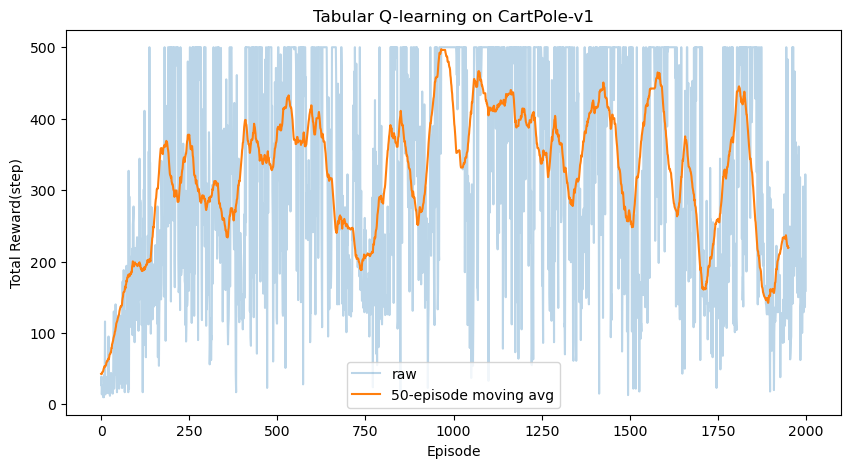

In [13]:
import matplotlib.pyplot as plt

window = 50
rewards = np.array(episode_reward)
moving_avg = np.convolve(rewards, np.ones(window) / window, mode = "valid")

plt.figure(figsize = (10, 5))

plt.plot(rewards, alpha = 0.3, label = "raw")
plt.plot(moving_avg, label = f"{window}-episode moving avg")

plt.xlabel("Episode")
plt.ylabel("Total Reward(step)")
plt.title("Tabular Q-learning on CartPole-v1")
plt.legend()
plt.savefig("../results/qlearning_cartpole.png")

plt.show()

# Multi-seed Experiment: Q-learning with Mean ± Std

A single training run is unreliable: RL has high variance, so the same code
can hit 500 one run and plateau at 176 the next. To get a statistically
meaningful result, train with multiple fixed seeds, then plot the mean curve
with a ±1 std shaded band. Fixed seeds also make the experiment reproducible.

### State Discretization

In [3]:
import gymnasium as gym
import numpy as np

env = gym.make("CartPole-v1")

N_BINS = (6, 6, 12, 12)
STATE_BOUNDS = [
     (-4.8, 4.8),
    (-3.0, 3.0),
    (-0.418, 0.418),
    (-3.5, 3.5),
]

def discretize(state):
    indices = []
    for i in range(4):
        low, high = STATE_BOUNDS[i]
        bins = np.linspace(low, high, N_BINS[i] + 1)[1: -1]
        idx = np.digitize(state[i], bins)

        indices.append(idx)

    return tuple(indices)



### Q-table Initialization

In [4]:
total_actions = env.action_space.n
q_table_shape = N_BINS + (total_actions,)
Q = np.zeros(q_table_shape)

### ε-greedy Action Selection

In [5]:
def choose_action(state, epsilon):
    if np.random.random() < epsilon:
        action = env.action_space.sample()

    else:
        s = discretize(state)
        action = np.argmax(Q[s])

    return action
    

### Q-learning Update Rule

In [6]:
def update(state, next_state, action, reward, done):
    s = discretize(state)
    s_next = discretize(next_state)
   

    if done:
        td_target = reward

    else:
        best_next = np.max(Q[s_next])
        td_target = reward + gamma * best_next
        
    td_error = td_target - Q[s][action]
    Q[s][action] = Q[s][action] + alpha * td_error
    

### Tabular Q-learning Training Pipeline

In [9]:

alpha = 0.1
gamma = 0.99

In [10]:
def train(seed):
    global Q
    Q = np.zeros(q_table_shape)

    np.random.seed(seed)
    env.action_space.seed(seed)
    env.reset(seed = seed)

    epsilon = 1.0
    min_epsilon = 0.05
    decay = 0.99
    n_episode = 2000
    episode_reward = []

    for episode in range(n_episode):
        state, info = env.reset()
        total_reward = 0
        done = False

        while not done:
            action = choose_action(state, epsilon)
            (next_state, reward, terminated, truncated, info) = env.step(action)
            done = terminated or truncated

            update(state, next_state, action, reward, done)
            state = next_state
            total_reward += reward

        episode_reward.append(total_reward)
        epsilon = max(min_epsilon, epsilon * decay)

    return np.array(episode_reward)
            
    

In [12]:
rewards = train(0)         
print(len(rewards))         
print(rewards[:5])         
print(max(rewards))         

2000
[22. 29. 16. 13. 17.]
180.0


### Multi-seed Training Loop

In [14]:
seeds = [0, 1, 2, 3, 4]
all_rewards = []

for seed in seeds:
    print(f"Training with seed {seed}")
    rewards = train(seed)
    all_rewards.append(rewards)

all_rewards = np.array(all_rewards)

print("shape", all_rewards.shape)


Training with seed 0
Training with seed 1
Training with seed 2
Training with seed 3
Training with seed 4
shape (5, 2000)


### Mean and Standard Deviation Aggregation

In [16]:
mean_rewards = all_rewards.mean(axis = 0)
std_rewards = all_rewards.std(axis = 0)

print("mean shape", mean_rewards.shape)
print("std shape", std_rewards.shape)

mean shape (2000,)
std shape (2000,)


### Learning Curve Visualization

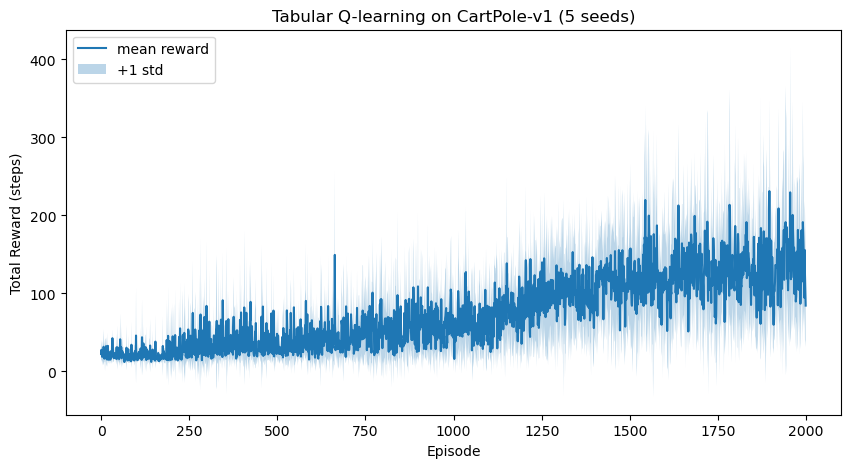

In [19]:
import matplotlib.pyplot as plt

episodes = np.arange(len(mean_rewards))

plt.figure(figsize = (10, 5))
plt.plot(episodes, mean_rewards, label = "mean reward")

plt.fill_between(
    episodes,
    mean_rewards - std_rewards,
    mean_rewards + std_rewards,
    alpha = 0.3,
    label = "+1 std"
)

plt.xlabel("Episode")
plt.ylabel("Total Reward (steps)")
plt.title("Tabular Q-learning on CartPole-v1 (5 seeds)")
plt.legend()
plt.savefig("../results/qlearning_cartpole_multiseed.png")
plt.show()
    